In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

In [5]:
import random

In [3]:
data_dir = r"D:\SmartVision\DataSets\smartvision_dataset\classification"

            Class  Count
0        airplane    100
1             bed    100
2           bench    100
3         bicycle    100
4            bird    100
5          bottle    100
6            bowl    100
7             bus    100
8            cake    100
9             car    100
10            cat    100
11          chair    100
12          couch    100
13            cow    100
14            cup    100
15            dog    100
16       elephant    100
17          horse    100
18     motorcycle    100
19         person    100
20          pizza    100
21   potted plant    100
22      stop sign    100
23  traffic light    100
24          train    100
25          truck    100


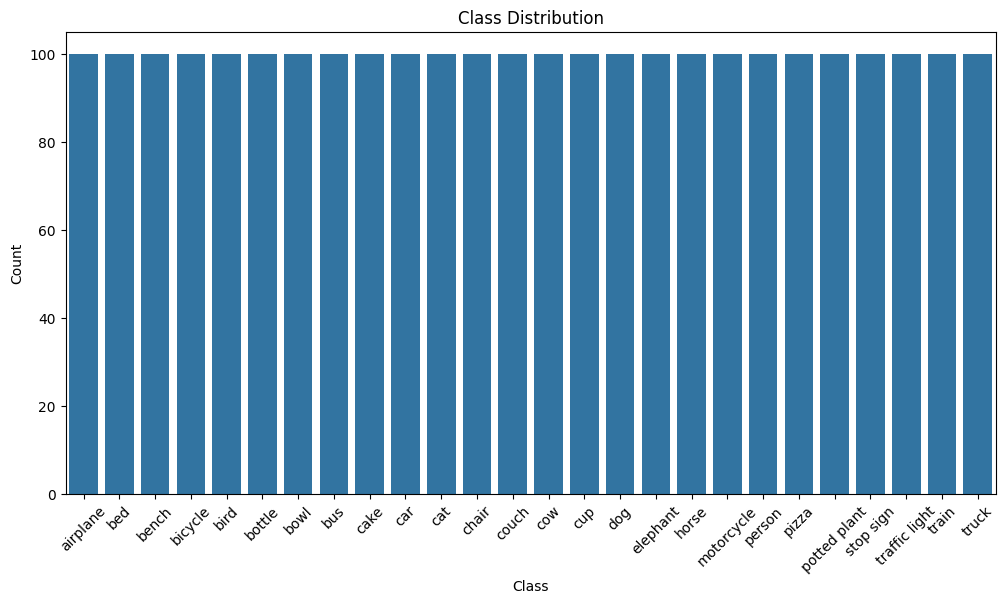

In [11]:
class_counts = {}

for split in ['train', 'val', 'test']:
    split_path = os.path.join(data_dir, split)
    
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            class_counts[cls] = class_counts.get(cls, 0) + count

# Convert to DataFrame
df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df = df.sort_values(by='Count', ascending=False)

print(df)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='Class', y='Count', data=df)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

In [12]:
print("Min images:", df['Count'].min())
print("Max images:", df['Count'].max())

Min images: 100
Max images: 100


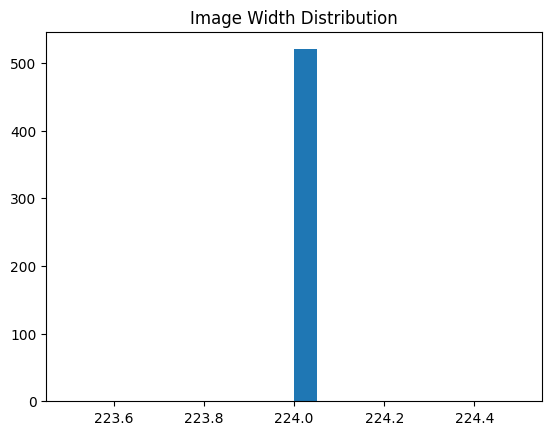

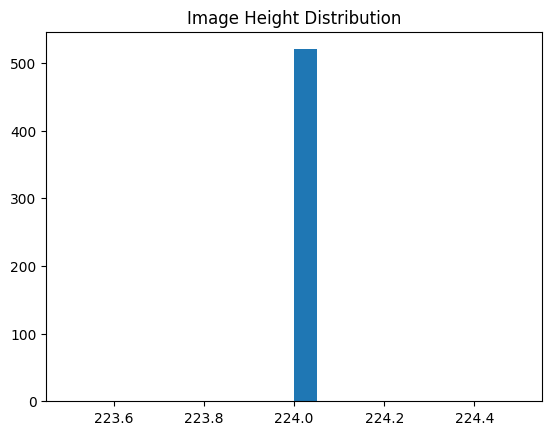

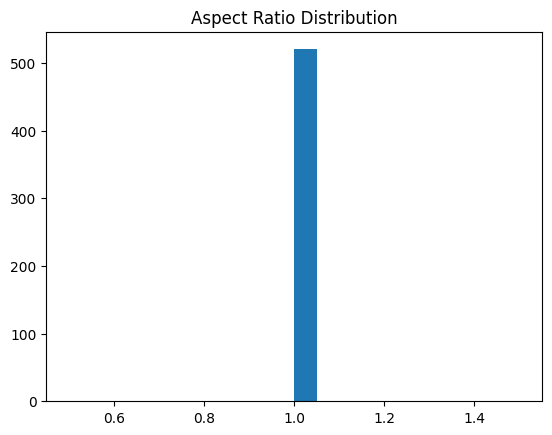

In [13]:
widths = []
heights = []

# Take sample images
for split in ['train']:
    split_path = os.path.join(data_dir, split)
    
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        
        for img_name in os.listdir(cls_path)[:20]:  # sample
            img_path = os.path.join(cls_path, img_name)
            
            try:
                img = Image.open(img_path)
                w, h = img.size
                widths.append(w)
                heights.append(h)
            except:
                continue

# Plot width
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.show()

# Plot height
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.show()

# Aspect ratio
aspect_ratios = [w/h for w, h in zip(widths, heights)]

plt.hist(aspect_ratios, bins=20)
plt.title("Aspect Ratio Distribution")
plt.show()

In [14]:
print("Objects per image ≈ 1 (classification dataset)")

Objects per image ≈ 1 (classification dataset)


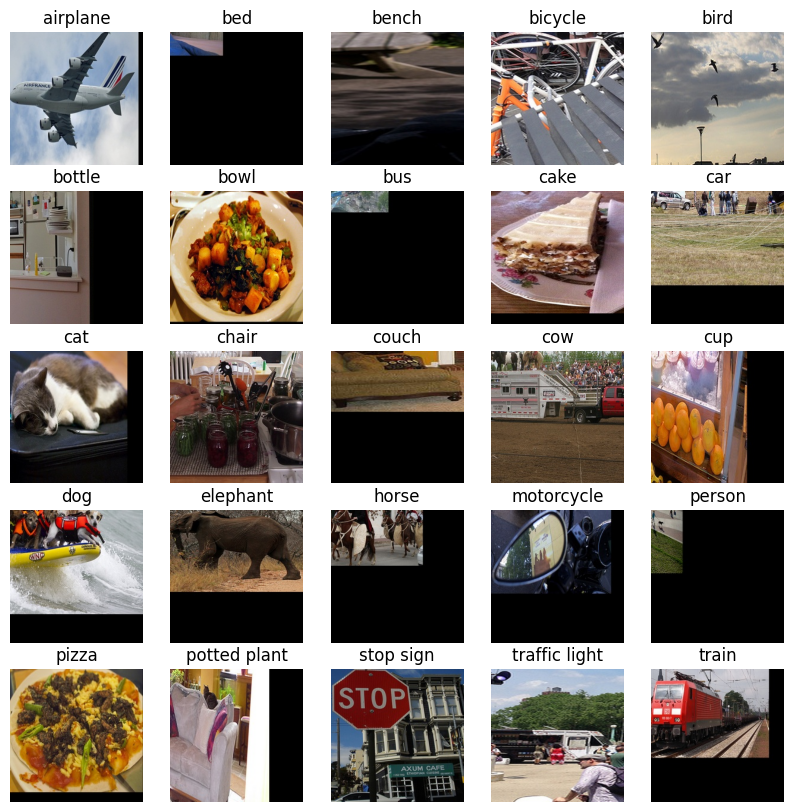

In [15]:
import random

plt.figure(figsize=(10,10))

i = 1
for cls in os.listdir(os.path.join(data_dir, 'train')):
    cls_path = os.path.join(data_dir, 'train', cls)
    
    images = os.listdir(cls_path)
    if len(images) == 0:
        continue
    
    img_path = os.path.join(cls_path, random.choice(images))
    
    img = Image.open(img_path)
    
    plt.subplot(5,5,i)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
    
    i += 1
    if i > 25:
        break

plt.show()

In [16]:
corrupted = 0

for split in ['train']:
    split_path = os.path.join(data_dir, split)
    
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            
            try:
                Image.open(img_path).verify()
            except:
                corrupted += 1

print("Corrupted Images:", corrupted)

Corrupted Images: 0


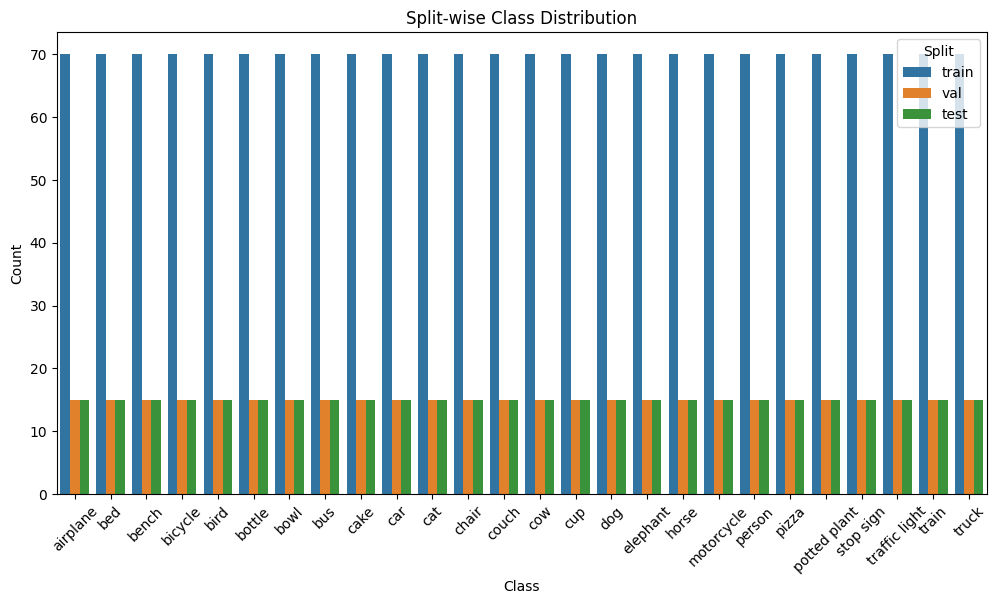

In [17]:
split_counts = []

for split in ['train', 'val', 'test']:
    split_path = os.path.join(data_dir, split)
    
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            split_counts.append([split, cls, count])

df_split = pd.DataFrame(split_counts, columns=['Split', 'Class', 'Count'])

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=df_split, x='Class', y='Count', hue='Split')
plt.xticks(rotation=45)
plt.title("Split-wise Class Distribution")
plt.show()

Split
test      390
train    1820
val       390
Name: Count, dtype: int64


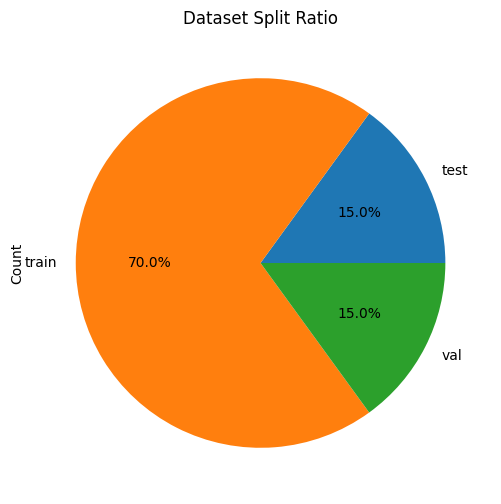

In [18]:
total = df_split.groupby('Split')['Count'].sum()
print(total)

total.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Dataset Split Ratio")
plt.show()

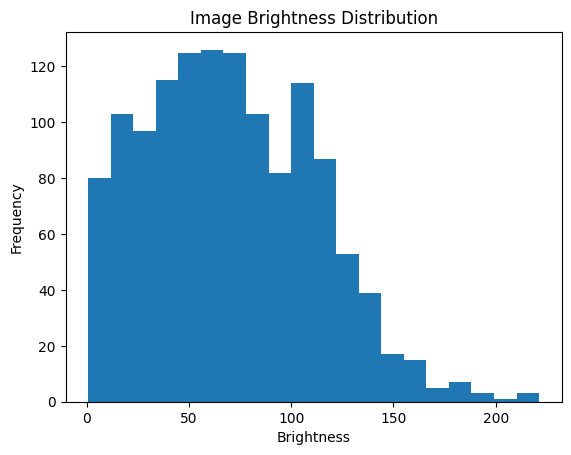

In [19]:
brightness = []

for cls in os.listdir(os.path.join(data_dir, 'train')):
    cls_path = os.path.join(data_dir, 'train', cls)
    
    for img_name in os.listdir(cls_path)[:50]:
        try:
            img = Image.open(os.path.join(cls_path, img_name)).convert('L')
            brightness.append(np.array(img).mean())
        except:
            continue

plt.hist(brightness, bins=20)
plt.title("Image Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")
plt.show()

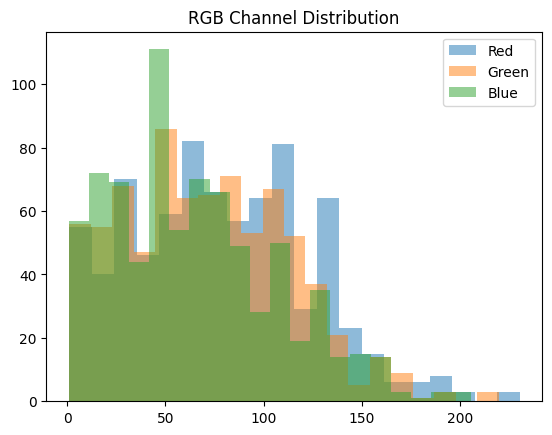

In [20]:
r, g, b = [], [], []

for cls in os.listdir(os.path.join(data_dir, 'train')):
    cls_path = os.path.join(data_dir, 'train', cls)
    
    for img_name in os.listdir(cls_path)[:30]:
        try:
            img = np.array(Image.open(os.path.join(cls_path, img_name)))
            r.append(img[:,:,0].mean())
            g.append(img[:,:,1].mean())
            b.append(img[:,:,2].mean())
        except:
            continue

plt.hist(r, bins=20, alpha=0.5, label='Red')
plt.hist(g, bins=20, alpha=0.5, label='Green')
plt.hist(b, bins=20, alpha=0.5, label='Blue')

plt.legend()
plt.title("RGB Channel Distribution")
plt.show()

In [21]:
sizes = []

for cls in os.listdir(os.path.join(data_dir, 'train')):
    cls_path = os.path.join(data_dir, 'train', cls)
    
    for img_name in os.listdir(cls_path)[:20]:
        try:
            img = Image.open(os.path.join(cls_path, img_name))
            sizes.append(img.size)
        except:
            continue

sizes_df = pd.DataFrame(sizes, columns=['Width', 'Height'])

print(sizes_df.describe())

       Width  Height
count  520.0   520.0
mean   224.0   224.0
std      0.0     0.0
min    224.0   224.0
25%    224.0   224.0
50%    224.0   224.0
75%    224.0   224.0
max    224.0   224.0


In [22]:
import hashlib

hashes = set()
duplicates = 0

for cls in os.listdir(os.path.join(data_dir, 'train')):
    cls_path = os.path.join(data_dir, 'train', cls)
    
    for img_name in os.listdir(cls_path):
        try:
            img_path = os.path.join(cls_path, img_name)
            with open(img_path, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
            
            if file_hash in hashes:
                duplicates += 1
            else:
                hashes.add(file_hash)
        except:
            continue

print("Duplicate Images:", duplicates)

Duplicate Images: 840


In [23]:
print("Top classes:\n", df.head())
print("\nBottom classes:\n", df.tail())

Top classes:
       Class  Count
0  airplane    100
1       bed    100
2     bench    100
3   bicycle    100
4      bird    100

Bottom classes:
             Class  Count
21   potted plant    100
22      stop sign    100
23  traffic light    100
24          train    100
25          truck    100


In [24]:
imbalance_ratio = df['Count'].max() / df['Count'].min()
print("Imbalance Ratio:", imbalance_ratio)

Imbalance Ratio: 1.0


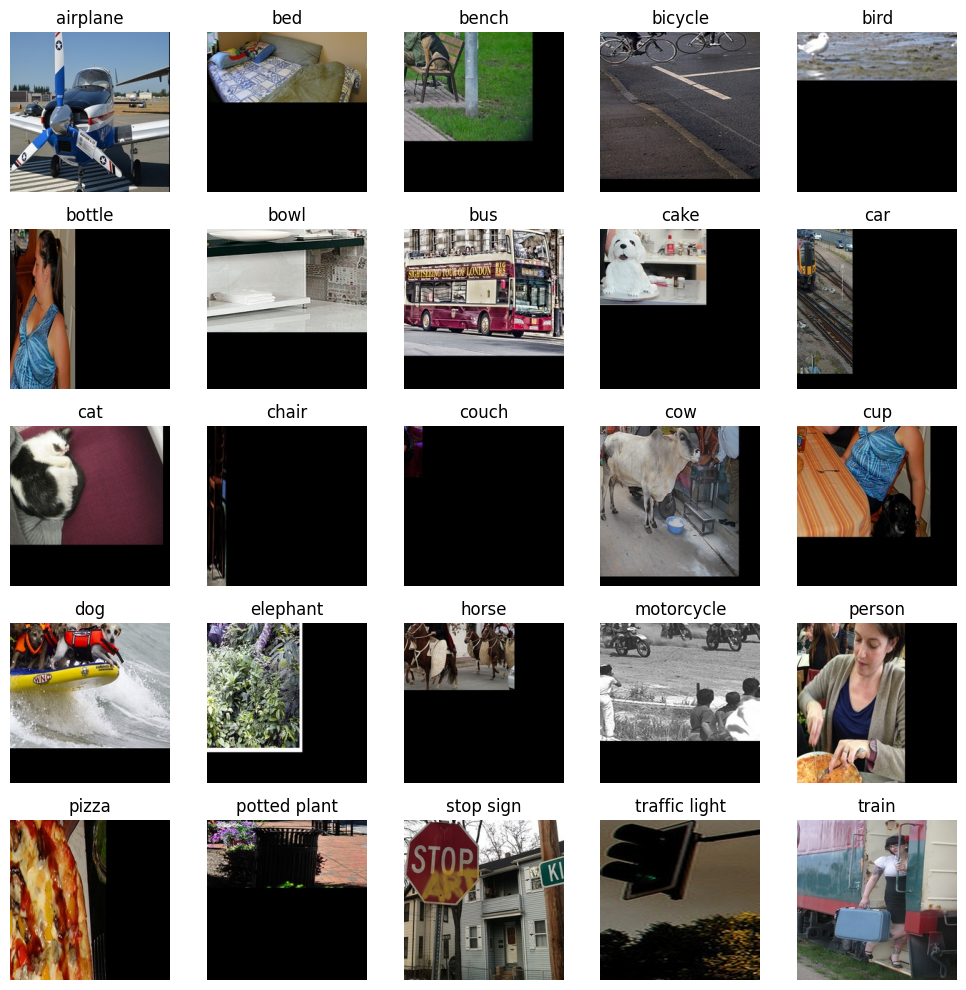

In [6]:
fig, axes = plt.subplots(5,5, figsize=(10,10))

classes = os.listdir(os.path.join(data_dir, 'train'))

for i, ax in enumerate(axes.flat):
    cls = classes[i]
    img_path = os.path.join(data_dir, 'train', cls, random.choice(os.listdir(os.path.join(data_dir, 'train', cls))))
    
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')

plt.tight_layout()
plt.show()